In [2]:
import pandas as pd

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [5]:
df = pd.read_csv("/workspaces/cyber-threat-log-analyzer/data/Global_Cybersecurity_Threats_2015-2024.csv")

In [8]:
df["High_Loss"] = (
    df["Financial Loss (in Million $)"] > df["Financial Loss (in Million $)"].median()
).astype(int)

In [9]:
X = df.drop("High_Loss", axis=1)
y = df["High_Loss"]

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#phase 13 #feature13.1 k croos validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

[1.         0.995      0.99833333 0.99666667 0.99833333]


In [ ]:
#feature 13.2 K-Fold-Cross-Validation
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf
)

print("Scores:", scores)
print("Average Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Scores: [0.99833333 0.99833333 0.99833333 0.995      0.99833333]
Average Accuracy: 0.9976666666666667
Standard Deviation: 0.0013333333333333196


In [13]:
#feature13.3 stratified K-Fold Cross Validation 
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# Create Stratified K-Fold Object
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform Cross Validation
scores = cross_val_score(
    model,
    X,
    y,
    cv=skf
)

print("Scores :", scores)
print("Average Accuracy :", scores.mean())
print("Standard Deviation :", scores.std())

Scores : [1.         1.         0.99833333 1.         0.99833333]
Average Accuracy : 0.9993333333333332
Standard Deviation : 0.0008164965809277449


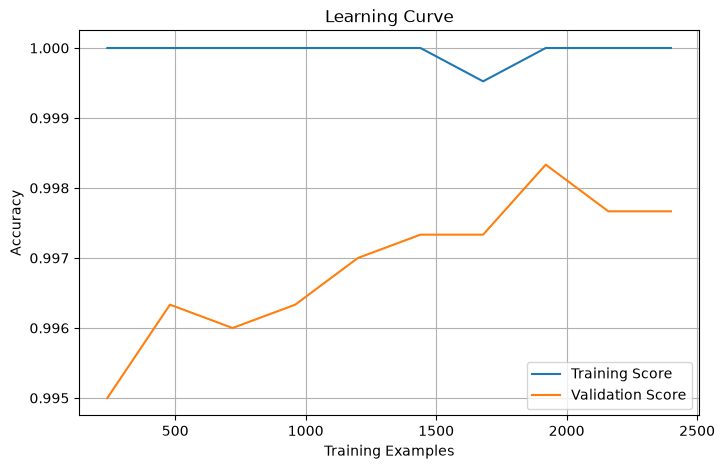

In [14]:
#feature 13.4 learning curves
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

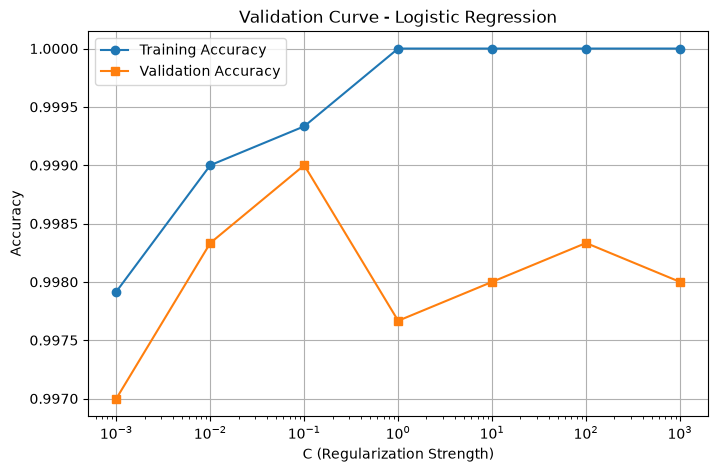

In [19]:
#FEATURE 13.5 validation curves 
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

# Different values of C to test
param_range = np.logspace(-3, 3, 7)

# Compute validation curve
train_scores, test_scores = validation_curve(
    estimator=model,
    X=X,
    y=y,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy"
)

# Mean accuracy across folds
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean,
         marker='o',
         label="Training Accuracy")

plt.plot(param_range, test_mean,
         marker='s',
         label="Validation Accuracy")

plt.xscale("log")   # Log scale because C varies exponentially

plt.xlabel("C (Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Validation Curve - Logistic Regression")

plt.legend()
plt.grid(True)

plt.show()

In [16]:
#feature 13.6 high biass and high variance 
from sklearn.tree import DecisionTreeClassifier

small_tree = DecisionTreeClassifier(max_depth=2)

large_tree = DecisionTreeClassifier(max_depth=20)